In [40]:
from astropy import units as u
from astropy.constants import G, c
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import spacehub_calc
from spacehub_calc import TwoBodyOrbit, mag
import matplotlib.animation as animation
from IPython.display import HTML
from orbits import distance, get_com, calc_angle
import orbits

$v_{\infty}^2 = 1.5  \frac{G m^2}{\mu a_b}$

$a_b = 10AU$

$r_{start} = 100AU$

$cos(i) = 1$

$b\in[1,40]AU$

In [41]:
m = 1 * u.Msun
a_b = 10 * u.AU
mu = m**2/(m+m)
v_inf = np.sqrt(1.5 * G * (m**2) / (a_b * mu))
v_inf.to(u.km/u.s)

<Quantity 16.31374758 km / s>

In [42]:
sample_file = "simulation_results/2+1_sample-3d.txt"
ptc_file = "simulation_results/2+1_ptcres-3demo.txt"
ordered_inputs = "simulation_results/ordered_inputs-3demo.txt"

In [43]:
indf = pd.read_csv(ordered_inputs)

In [44]:
data = orbits.load_spacehub_data(ptc_file)[1]

In [45]:
npoints = len(data["time"])
data["ecc01"] = mag(orbits.get_ecc(data, 0, 1))
data["ecc02"] = mag(orbits.get_ecc(data, 0, 2))
data["ecc12"] = mag(orbits.get_ecc(data, 1, 2))
data["rx01"], data["ry01"], data["rz01"] = distance(data, 'p', 0, 1)
data["rx02"], data["ry02"], data["rz02"] = distance(data, 'p', 0, 2)
data["rx12"], data["ry12"], data["rz12"] = distance(data, 'p', 1, 2)

In [46]:
result_df = pd.DataFrame(columns=["b", "azi", "incl", "ionized", "outcome", "rx01", "ry01", "rz01", "rx02", "ry02", "rz02", "rx12", "ry12", "rz12"])
for i in range(0, npoints):
    row = {}
    row["b"] = indf.at[i, "b"]
    row["azi"] = indf.at[i, "azi"]
    row["incl"] = indf.at[i, "incl"]
    row["ionized"] = 1 if data["ecc01"][i]  >= 1 else 0
    e_ij = np.array([data["ecc01"][i], data["ecc02"][i], data["ecc12"][i]])
    bound = np.where((e_ij > 0) & (e_ij < 1))[0]
    if len(bound) == 0:
        row["outcome"] = "Unbound"
    elif bound[0] == 0:
        row["outcome"] = "a-b"
    elif bound[0] == 1:
        row["outcome"] = "a-I"
    elif bound[0] == 2:
        row["outcome"] = "b-I"
    if len(bound) > 1:
        print(f"triple: {i}")
        row["outcome"] = "Trinary"
    #add distances in case I want to plot in cartesian
    row["rx01"], row["ry01"], row["rz01"] = data["rx01"][i], data["ry01"][i], data["rz01"][i]
    row["rx02"], row["ry02"], row["rz02"] = data["rx02"][i], data["ry02"][i], data["rz02"][i]
    row["rx12"], row["ry12"], row["rz12"] = data["rx12"][i], data["ry12"][i], data["rz12"][i]
    result_df = pd.concat([result_df, pd.DataFrame(row, index=[len(result_df)])])
        
result_df
    

,b,azi,incl,ionized,outcome,rx01,ry01,rz01,rx02,ry02,rz02,rx12,ry12,rz12
0,1.0,0.00000,0.000000,1,b-I,-383.5830,-296.1038,0.000000e+00,-393.4920,-298.3490,0.000000e+00,-9.9090,-2.2452,0.000000e+00
1,1.0,0.00000,0.165347,1,b-I,-381.0780,-290.4552,-3.946940e+01,-388.3290,-289.6369,-3.686920e+01,-7.2510,0.8183,2.600200e+00
2,1.0,0.00000,0.330694,1,b-I,-369.1680,-270.3981,-7.311280e+01,-376.7130,-270.6819,-6.838010e+01,-7.5450,-0.2838,4.732700e+00
3,1.0,0.00000,0.496041,1,b-I,-354.4740,-244.5149,-9.870820e+01,-351.4620,-242.3249,-9.162420e+01,3.0120,2.1900,7.084000e+00
4,1.0,0.00000,0.661388,1,b-I,-332.2380,-215.7614,-1.138082e+02,-317.8770,-210.6858,-1.109726e+02,14.3610,5.0756,2.835600e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,30.0,6.28319,2.480200,0,a-b,5.0901,-7.9940,3.317000e-01,-117.1820,-351.9280,2.715201e+02,-122.2721,-343.9340,2.711884e+02
1196,30.0,6.28319,2.645550,0,a-b,1.3930,-9.4170,1.468000e-01,-120.7194,-391.7220,2.096203e+02,-122.1124,-382.3050,2.094735e+02
1197,30.0,6.28319,2.810900,0,a-b,-1.3786,-9.5370,2.350000e-02,-123.4691,-420.2400,1.425794e+02,-122.0905,-410.7030,1.425559e+02
1198,30.0,6.28319,2.976250,0,a-b,-2.9830,-9.2670,-1.450000e-02,-125.1573,-437.3850,7.213580e+01,-122.1743,-428.1180,7.215030e+01


Text(0, 0.5, '$R_{y,0}$')

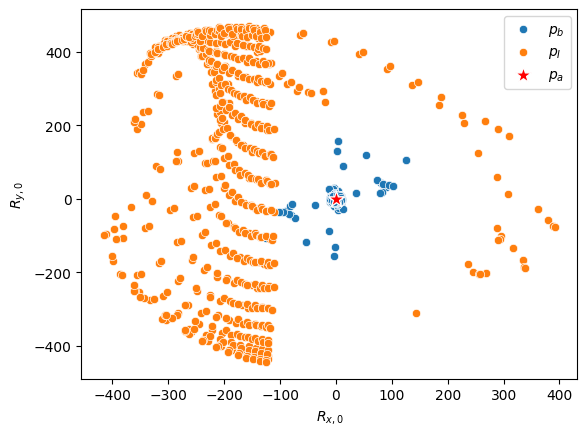

In [47]:
unionized = result_df[(result_df["ionized"]==0) & (result_df["outcome"] != "123")] #Ignore the 4 cases where all 3 particles remained bound
fig, ax = plt.subplots()
sns.scatterplot(unionized, x="rx01", y="ry01", ax=ax, label=r"$p_b$")
sns.scatterplot(unionized, x="rx02", y="ry02", ax=ax, label=r"$p_I$")
sns.scatterplot(x=[0], y=[0], ax=ax, label=r"$p_a$", marker='*', s=150, c='red')
ax.legend()
ax.set_xlabel(r"$R_{x,0}$")
ax.set_ylabel(r"$R_{y,0}$")


Text(0.6944444444444446, 0.5, '$f_{ionized}$')

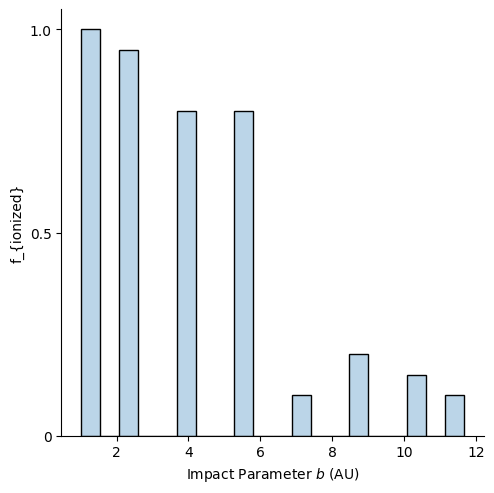

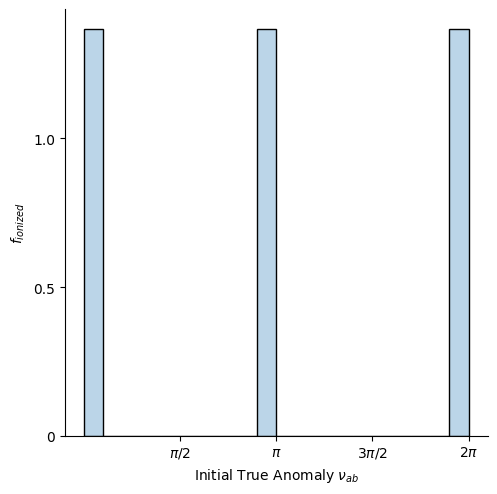

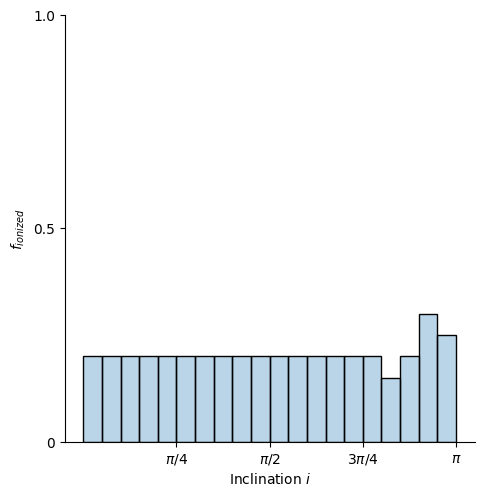

In [48]:
#ab = 10AU
ionized_mask = result_df["ionized"] == 1
b_len = len(result_df)/result_df["b"].nunique()
g = sns.displot(result_df[ionized_mask], x="b", bins=result_df["b"].nunique(), alpha=0.3)
g.ax.set_yticks([0, (b_len/2), b_len])
g.ax.set_ylabel(r"f_{ionized}")
g.ax.set_xlabel(r"Impact Parameter $b$ (AU)")
g.ax.set_yticklabels([0, 0.5, 1.0])

azi_len = len(result_df)/result_df["azi"].nunique()
g = sns.displot(result_df[ionized_mask], x="azi", bins=result_df["b"].nunique(), alpha=0.3)
g.ax.set_yticks([0, (b_len/2), b_len])
g.ax.set_yticklabels([0, 0.5, 1.0])
g.ax.set_xticks([np.pi/2, np.pi, 1.5*np.pi, 2*np.pi])
g.ax.set_xticklabels([ r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
g.ax.set_xlabel(r"Initial True Anomaly $\nu_{ab}$")
g.ax.set_ylabel(r"$f_{ionized}$")

incl_len = len(result_df)/result_df["incl"].nunique()
g = sns.displot(result_df[ionized_mask], x="incl", bins=result_df["incl"].nunique(), alpha=0.3)
g.ax.set_yticks([0, (b_len/2), b_len])
g.ax.set_yticklabels([0, 0.5, 1.0])
g.ax.set_xticks([np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
g.ax.set_xticklabels([ r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
g.ax.set_xlabel(r"Inclination $i$")
g.ax.set_ylabel(r"$f_{ionized}$")



In [49]:
sigma_ion = 2*np.pi * (max(result_df[ionized_mask]["b"]) * u.AU)**2
sigma_ion.si

<Quantity 1.91967919e+25 m2>

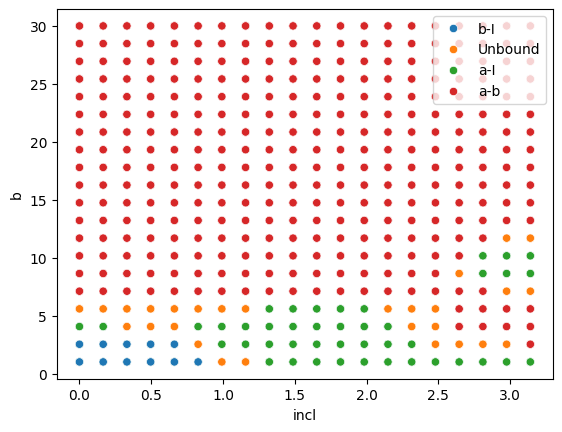

In [54]:
sns.scatterplot(result_df, x='incl', y='b', hue='outcome')
plt.legend(loc='upper right')

In [51]:
25*25*25

15625